# Weiss Schwarz Finisher Simulator — Practical Example

This notebook walks through a full use of the simulator: define a deck, define attack
sequences in the occurrence DSL, run a Monte Carlo simulation, and read the resulting
damage-probability results.

The syntax reference for the DSL (`BURN`, `MILL`, `TOPCHECK`, ...) lives in `README.md` —
this notebook focuses on *using* the simulator, not on the grammar itself.

**What we're testing.** Two attack sequences of the same length (6 occurrences each), built
from different DSL keywords, against the *same* opponent deck size but across a **range of
climax counts (4, 6, 8)**: does a mill-based sequence deal more or less damage than a
straightforward triggered-burn sequence, and does that comparison hold up as the opponent's
climax ratio changes — not just at one fixed build?

## 1. Defining a deck

A deck is described as two dictionaries of `{Card(level, soul_trigger, category, color): count}`:
one for non-climax cards, one for climax cards. The simulator draws decks randomly from these
pools according to the given ratios, so a deck definition is really a *distribution* over decks,
not one fixed decklist.

Two roles matter here, per the simulator's convention: the **main deck** is the *opponent's*
deck — the one taking damage, and whose climaxes can cancel an attack — while the **trigger
deck** is the *attacking player's own* deck, the source of the trigger checks (`/A`, `/T`) that
add bonus damage. We reuse the same card pool for both roles below for simplicity (symmetric
matchup); in practice you'd give each side its own curve.

We fix the opponent's **deck size at 25 cards** and sweep their **climax count over (4, 6, 8)**,
so we can see whether the comparison between sequences holds across different climax ratios,
rather than relying on a single build.

In [1]:
from simulateur import Card, SimulationConfig, generate_table
import pandas as pd
import matplotlib.pyplot as plt

non_climax_specs = {
    Card(0, 0, "character", "yellow"): 17,
    Card(1, 0, "character", "yellow"): 12,
    Card(2, 1, "character", "yellow"): 3,
    Card(3, 0, "character", "yellow"): 3,
    Card(3, 1, "character", "yellow"): 7,
}
climax_specs = {
    Card(0, 0, "climax", "yellow"): 4,
    Card(0, 1, "climax", "yellow"): 4,
}

## 2. Defining two attack sequences

Both sequences use **6 occurrences**, so neither has more "chances to act" than the other —
any difference in output comes from what each occurrence does, not from how many there are.

- **`burn_only`** — three repetitions of burn 4 followed by an 3-damage auto-attack
  with a single trigger check (`/A`). Every occurrence is a guaranteed-target `BURN`.
- **`mill_each`** — three repetitions of milling 3 cards from the opponent's deck and resolving
  a `BURN(2)` for each climax found among them (`MILL(3) OPP BOTTOM EACH[BURN(2)]`), each
  followed by the same triggered `BURN(3)/A`. Every other occurrence's damage is conditional on
  what gets milled, instead of being a fixed, guaranteed amount.

In [2]:
sequences = {
    "burn_only": ["BURN(4)", "BURN(3)/A", "BURN(4)", "BURN(3)/A", "BURN(4)", "BURN(3)/A"],
    "mill_each": [
        "MILL(3) OPP BOTTOM EACH[BURN(2)]", "BURN(3)/A",
        "MILL(3) OPP BOTTOM EACH[BURN(2)]", "BURN(3)/A",
        "MILL(3) OPP BOTTOM EACH[BURN(2)]", "BURN(3)/A",
    ],
}

## 3. Running the simulation

One `generate_table` run per sequence, opponent deck size fixed at 25, climax count swept over
`(4, 6, 8)`, 20,000 trials per combination for smooth tails, `seed=42` for reproducibility. We
keep every damage threshold — the point is to compare the *whole* distribution at each climax
level, not a single cutoff.

In [3]:
climax_values = (4, 6, 8)

tables = []
for name, occ in sequences.items():
    config = SimulationConfig(
        deck_size_list=[25],
        climax_list=list(climax_values),
        occurrences=occ,
        n_trials=20000,
        main_non_climax_specs=non_climax_specs,
        main_climax_specs=climax_specs,
        trigger_non_climax_specs=non_climax_specs,
        trigger_climax_specs=climax_specs,
        trigger_deck_size=16,
        trigger_deck_climax=0,
        trigger_deck_stock_size=2,
        main_deck_stock_size=2,
        n_jobs=1,
        seed=42,
    )
    table = generate_table(config)
    table["sequence"] = name
    tables.append(table)

results = pd.concat(tables, ignore_index=True)
damage_cols = [c for c in results.columns if c.startswith("P(total_damage>=")]

# Once P(X>=k) reaches below a certain point, we trim the tail
epsilon = 0.005
still_relevant = results[damage_cols].max(axis=0) >= epsilon
last_relevant_idx = still_relevant[::-1].idxmax()  # last True column, scanning from the end
cutoff = damage_cols.index(last_relevant_idx) + 1  # +1 to keep one extra column past the cutoff
damage_cols = damage_cols[:cutoff]

results[["sequence", "climax_number"] + damage_cols]

,sequence,climax_number,P(total_damage>=0),P(total_damage>=1),P(total_damage>=2),P(total_damage>=3),P(total_damage>=4),P(total_damage>=5),P(total_damage>=6),P(total_damage>=7),...,P(total_damage>=9),P(total_damage>=10),P(total_damage>=11),P(total_damage>=12),P(total_damage>=13),P(total_damage>=14),P(total_damage>=15),P(total_damage>=16),P(total_damage>=17),P(total_damage>=18)
0,burn_only,4,1.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9728,...,0.8009,0.7822,0.5983,0.3346,0.2628,0.2266,0.1042,0.0294,0.0184,0.0111
1,burn_only,6,1.0,0.9882,0.9882,0.9882,0.9012,0.7896,0.7896,0.7071,...,0.2978,0.2852,0.1803,0.0560,0.0305,0.0239,0.0076,0.0008,0.0005,0.0002
2,burn_only,8,1.0,0.8796,0.8796,0.8796,0.6642,0.4240,0.4240,0.3478,...,0.0642,0.0593,0.0319,0.0050,0.0014,0.0010,0.0002,0.0000,0.0000,0.0000
3,mill_each,4,1.0,0.9749,0.9749,0.9517,0.8550,0.8275,0.7151,0.6096,...,0.3590,0.2761,0.1958,0.1410,0.0855,0.0400,0.0194,0.0115,0.0088,0.0081
4,mill_each,6,1.0,0.9508,0.9508,0.8774,0.7840,0.7232,0.5758,0.4871,...,0.2519,0.1795,0.1198,0.0803,0.0440,0.0248,0.0138,0.0074,0.0052,0.0038
5,mill_each,8,1.0,0.9218,0.9218,0.7881,0.7020,0.5985,0.4572,0.3628,...,0.1622,0.1064,0.0687,0.0427,0.0259,0.0145,0.0060,0.0022,0.0016,0.0008


## 4. Reading the results

Each column `P(total_damage>=t)` is the share of trials that dealt **at least** `t` damage —
a survival curve, now computed separately for every (sequence, climax count) pair. The table
is trimmed once every curve has dropped below 0.5% probability, so we're not scrolling through
a long tail of near-zero columns.

## 5. Visualizing the full survival curves, across climax counts

All six curves (2 sequences x 3 climax counts) on one plot, colored by sequence and styled by
climax count, so the shrinking gap between `burn_only` and `mill_each` as climax count rises is
visible directly, without splitting the eye across separate panels.

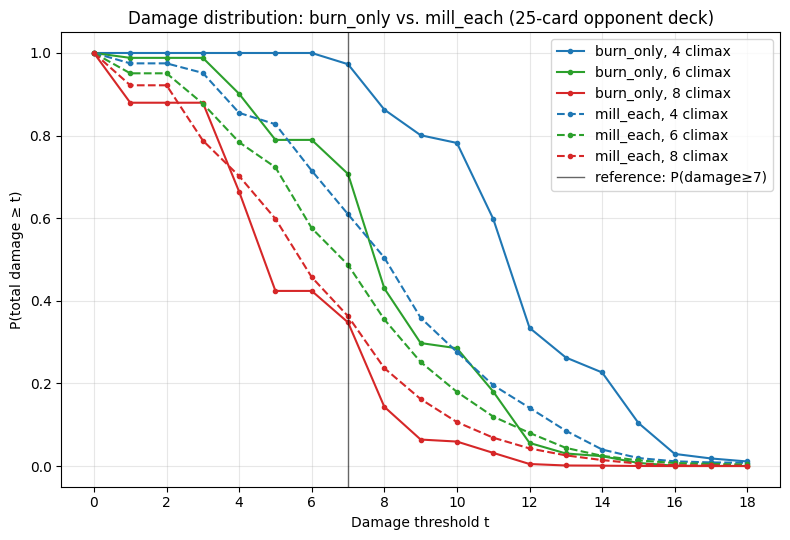

In [4]:
thresholds = [int(c.split(">=")[1][:-1]) for c in damage_cols]
linestyles = {"burn_only": "-", "mill_each": "--"}
colors = {4: "tab:blue", 6: "tab:green", 8: "tab:red"}

fig, ax = plt.subplots(figsize=(8, 5.5))
for (name, climax_n), group in results.groupby(["sequence", "climax_number"]):
    row = group.iloc[0]
    ax.plot(
        thresholds, row[damage_cols].values,
        marker="o", markersize=3,
        color=colors[climax_n], linestyle=linestyles[name],
        label=f"{name}, {climax_n} climax",
    )

ax.axvline(7, color="black", linestyle="-", linewidth=1, alpha=0.6, label="reference: P(damage≥7)")
ax.set_xlabel("Damage threshold t")
ax.set_ylabel("P(total damage ≥ t)")
ax.set_xticks(range(0, max(thresholds) + 1, 2))
ax.set_title("Damage distribution: burn_only vs. mill_each (25-card opponent deck)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Takeaway

`burn_only` dominates heavily at low climax counts, but the gap **closes and reverses** as
climax count rises. At `P(total_damage>=7)`, `burn_only` leads by **36.3 percentage points**
at 4 climax (0.973 vs 0.610) and by **22.0 points** at 6 climax (0.707 vs 0.487) — but at
8 climax, `mill_each` actually **edges ahead** (0.363 vs 0.348, a 1.5-point lead).

Each `MILL(3) OPP BOTTOM EACH[BURN(2)]` occurrence has its own independent chance to find
climaxes among the 3 cards milled, and `mill_each` repeats that occurrence three times. A
higher climax ratio in the opponent's deck raises that chance every time, so across three
repetitions the compounded payoff eventually catches up with, and slightly passes, a sequence
built entirely on guaranteed-hit `BURN`s. Whether that reversal holds up against other deck
sizes or mill amounts is exactly the kind of follow-up question the simulator is built to check
rather than guess at.